In [1]:
# try:
#   from google.colab import drive
#   drive.mount('/content/drive')

#   %cd /content/drive/My Drive/spResources/zzzfinalTesting
# except Exception as e:
#   print("Error: ", e)

In [2]:
# First, uninstall potentially conflicting versions
%pip uninstall -y mediapipe protobuf

# Install a compatible protobuf version that mediapipe 0.10.x often works with
# Note: This might break other packages that require a newer protobuf. If so, other solutions like upgrading mediapipe or virtual environments may be needed.
%pip install protobuf==3.20.3

# Then install mediapipe and other libraries
%pip install numpy opencv-python tensorflow

# %pip uninstall mediapipe
%pip install "mediapipe<0.10.30"

Found existing installation: mediapipe 0.10.21
Uninstalling mediapipe-0.10.21:
  Successfully uninstalled mediapipe-0.10.21
Found existing installation: protobuf 4.25.8
Uninstalling protobuf-4.25.8:
  Successfully uninstalled protobuf-4.25.8
Note: you may need to restart the kernel to use updated packages.
  Using cached protobuf-3.20.3-py2.py3-none-any.whl.metadata (720 bytes)
Using cached protobuf-3.20.3-py2.py3-none-any.whl (162 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached numpy-2.2.6-cp312-cp312-win_amd64.whl.metadata (60 kB)
  Using cached numpy-2.1.3-cp312-cp312-win_amd64.whl.metadata (60 kB)
Using cached numpy-2.1.3-cp312-cp312-win_amd64.whl (12.6 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached mediapipe-0.10.21-cp312-cp312-win_amd64.whl.metadata (10 kB)
  Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl.metadata (61 kB)
  Using cached protobuf-4.25.8-cp310-abi3-win_amd64.whl.metadata (541 bytes)
Using cached mediapipe-0.10.21-cp312-cp312-win_amd64.whl (51.0 MB)
Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl (15.5 MB)
Using cached protobuf-4.25.8-cp310-abi3-win_amd64.whl (413 kB)

  Attempting uninstall: protobuf

    Found existing installation: protobuf 3.20.3

    Uninstalling protobuf-3.20.3:

   ---------------------------------------- 0/3 [protobuf]
   ---------------------------------------- 0/3 [protobuf]
      Successfully uninstalled protobuf-3.20.3
   ---------------------------------------- 0/3 [protobuf]
   ---------------------------------------- 0/3 [protobuf]
   ---------------------------------------- 0/3 [protobuf]
   ---------------------------------------- 0/3 [protobuf]
  Attempting uninstall: numpy
   ------------------------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import cv2
import mediapipe as mp
import numpy as np
import os
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras.layers import LSTM, Dense, Input, Dropout, Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.callbacks import TensorBoard
from sklearn.metrics import multilabel_confusion_matrix, accuracy_score
from collections import deque

from utils import mediapipeDetection, extractLandmarks, checkVelocity, extractFaceLandmarks, extractPoseLandmarks

In [4]:
# subject to changes later on
# for now set to testing

DATA_PATH = "trainingMPData"
labels = np.array(["goodMorning","goodAfternoon","goodEvening","hello","howAreYou","imFine","niceToMeetYou","thankYou","youreWelcome","seeYouTomorrow"])
moodArr = np.array(['neutral', 'question'])
noActionVideos = 13

counter = 0
for label in labels:
    for videoAction in range(noActionVideos*5):  # 5 data augmentations: normal, mirror, jitter, time warp fast, time warp slow
        try:
            os.makedirs(os.path.join(DATA_PATH, str(counter)+label, str(videoAction)))
        except: pass
    counter += 1

In [5]:
import re # Import regex for natural sorting

#Build keypoints using MP Holistic
mpHolistic = mp.solutions.holistic     #Holistic Model
mpDrawing = mp.solutions.drawing_utils #Drawing Utilities

def natural_sort_key(s):
    """Key for natural sorting (e.g., '10' after '2')."""
    return [int(text) if text.isdigit() else text.lower() for text in re.split('([0-9]+)', s)]

def find_video_files(directory, labels_array, num_videos_per_label):
    video_extensions = ('.mov', '.mp4')
    ordered_video_files_paths = []

    for i, label in enumerate(labels_array):
        label_dir = os.path.join(directory, str(i)) # e.g., /clips/0, /clips/1
        if not os.path.exists(label_dir):
            print(f"Warning: Directory {label_dir} not found. Skipping label {label}.")
            continue

        current_label_videos = []
        # Sort files using natural sorting to ensure correct numerical order
        for filename in sorted(os.listdir(label_dir), key=natural_sort_key):
            if filename.lower().endswith(video_extensions):
                full_path = os.path.join(label_dir, filename)
                current_label_videos.append(full_path)

        # Take only the specified number of videos for this label
        # This handles cases where there might be more files than noActionVideos
        ordered_video_files_paths.extend(current_label_videos[:num_videos_per_label])

    return ordered_video_files_paths

In [6]:
def find_image_files(directory, labels_array, num_images_per_label):
    image_extensions = ('.jpg', '.jpeg', '.png')
    ordered_image_files_paths = []

    for i, label in enumerate(labels_array):
        label_dir = os.path.join(directory, label) # e.g., /clips/0, /clips/1
        if not os.path.exists(label_dir):
            print(f"Warning: Directory {label_dir} not found. Skipping label {label}.")
            continue

        current_label_images = []
        # Sort files using natural sorting to ensure correct numerical order
        for filename in sorted(os.listdir(label_dir), key=natural_sort_key):
            if filename.lower().endswith(image_extensions):
                full_path = os.path.join(label_dir, filename)
                current_label_images.append(full_path)

        # Take only the specified number of images for this label
        # This handles cases where there might be more files than noActionImages
        ordered_image_files_paths.extend(current_label_images[:num_images_per_label])

    return ordered_image_files_paths

In [7]:
# input expected to be (258,) array
# just pose and right and left arms and hands, no face
def gaussianJitter(frameArr):
    frameCopy = frameArr.copy()
    non_zero_mask = frameCopy != 0
    num_non_zero = np.sum(non_zero_mask)
    jitter_values = np.random.normal(0.0, 0.005, num_non_zero)
    frameCopy[non_zero_mask] += jitter_values

    return frameCopy

In [8]:
def timeWarpSplit(fullData, targetLen):
    """
    Returns 2 augmented versions of fullData:
    Index 0: Sped Up (Action finishes early, holds last frame)
    Index 1: Slowed Down (Action gets cut off)
    """
    dataCopy = fullData.copy()
    num_frames, num_features = dataCopy.shape
    
    # 1. Define standard query points (0, 1, 2... targetLen)
    query_timeline = np.arange(targetLen)
    
    # 2. Define Rates
    # < 1.0 means data timeline is compressed (Action happens 'sooner' -> FAST)
    # > 1.0 means data timeline is stretched (Action happens 'later' -> SLOW)
    fast_rate = np.random.uniform(0.7, 0.9)  # e.g., 80% duration
    slow_rate = np.random.uniform(1.1, 1.3)  # e.g., 120% duration

    # 3. Create the two warped timelines (The 'xp' for interpolation)
    # We maintain the start at 0, but allow the end to float
    timeline_fast = np.arange(num_frames) * fast_rate
    timeline_slow = np.arange(num_frames) * slow_rate

    # Sort to ensure monotonicity (required for np.interp)
    timeline_fast.sort()
    timeline_slow.sort()

    # 4. Prepare Output Container (2 sets of data)
    augmented_batch = np.zeros((2, targetLen, num_features))

    # 5. Interpolate
    for i in range(num_features):
        feature_data = dataCopy[:, i]
        
        # Generate Fast Version
        augmented_batch[0, :, i] = np.interp(query_timeline, timeline_fast, feature_data)
        
        # Generate Slow Version
        augmented_batch[1, :, i] = np.interp(query_timeline, timeline_slow, feature_data)

    return augmented_batch

In [9]:
def addFullVelocity(fullData):
  dataCopy = fullData.copy()

  velocityArr = np.diff(dataCopy, axis=0)
  padding = np.zeros_like(velocityArr[:1], dtype=np.float32)      # creates a padding based on the shape of one the landmarks of the frame
  velocityArr = np.concatenate((padding, velocityArr), axis=0)    # completed velocity array

  return np.concatenate((dataCopy, velocityArr), axis=1)

In [10]:
def finalFrameHandling(fullData, missingFrames):
    last_frame_padding = [fullData[-1].copy() for _ in range(missingFrames)]
    dataCopy = fullData.copy()

    dataCopy.extend(last_frame_padding)
    return dataCopy

In [11]:
def process_video_in_folders(root_directory):
    video_directory = os.path.join(root_directory, "training")

    videos = find_video_files(video_directory, labels, noActionVideos)

    if not videos:
        print(f"No video files found in: {video_directory}")
        print("error here")

    print(f"Found {len(videos)} video files:")

    currAction = 0
    frameLimit = 240    # hard limit
    mpFrameLimit = 40   # reduced to 40 for faster processing and is adjusted for 30 fps camera feed
    videoNum = 0
    TRAINING_PATH = "trainingMPData"


    for video_path in videos:
        print(f"\nProcessing: {video_path}")
        cap = cv2.VideoCapture(video_path)
        currFrameCount = 0 # current frame count
        mpFrameCount = 0
        actionStart = False
        fullNoAugmentationResult = []
        fullFlipResult = []
        fullJitterResult = []

        with mpHolistic.Holistic(min_detection_confidence=0.75, min_tracking_confidence=0.75) as holistic:
            while cap.isOpened():
                ret,frame = cap.read()
                if not ret: break
                if mpFrameCount >= mpFrameLimit or currFrameCount >= frameLimit: break

                _, results = mediapipeDetection(frame, holistic)
                actionLmk = extractPoseLandmarks(results)

                # New Velocity Check
                if currFrameCount == 0:
                    currFrame = actionLmk
                    prevFrame = None

                if currFrameCount > 0 and not actionStart:
                    prevFrame = currFrame
                    currFrame = actionLmk

                if not actionStart and prevFrame is not None:
                    if checkVelocity(currFrame, prevFrame):
                        actionStart = True
                        print(f"starts at frame {currFrameCount}")

                # strictly takes only every 3rd frame for MP data; subject to change later on
                if actionStart and mpFrameCount < mpFrameLimit and currFrameCount % 3 == 0:
                    # data augmentation: None
                    fullNoAugmentationResult.append(actionLmk)

                    # data augmentation: mirror flip
                    flipFrame = cv2.flip(frame, 1) # horizontal flip
                    _, flipResults = mediapipeDetection(flipFrame, holistic)
                    flipActionLmk = extractPoseLandmarks(flipResults)
                    fullFlipResult.append(flipActionLmk)

                    # data augmentation: jitter
                    jitterFrame = gaussianJitter(actionLmk)
                    fullJitterResult.append(jitterFrame)

                    mpFrameCount += 1

                currFrameCount += 1

            # If we didn't get enough frames (e.g., got 38, need 40)
            missing_frames = mpFrameLimit - mpFrameCount
            # 4. If we want to pad with the last frame instead of zeros:
            if missing_frames > 0:
                fullNoAugmentationResult = finalFrameHandling(fullNoAugmentationResult, missing_frames)
                fullFlipResult = finalFrameHandling(fullFlipResult, missing_frames)
                fullJitterResult = finalFrameHandling(fullJitterResult, missing_frames)
                print(f"Video had only {mpFrameCount} MP frames. Added {missing_frames} frames of padding to reach {mpFrameLimit} frames.")

            fullFlipResult = addFullVelocity(np.array(fullFlipResult))
            fullJitterResult = addFullVelocity(np.array(fullJitterResult))

            # handle Time warping separately here since it requires the full data to create the augmentations
            timeWarpResultsFast, timeWarpResultsSlow = timeWarpSplit(np.array(fullNoAugmentationResult), mpFrameLimit)
            fullNoAugmentationResult = addFullVelocity(np.array(fullNoAugmentationResult))
            timeWarpResultsFast = addFullVelocity(timeWarpResultsFast)
            timeWarpResultsSlow = addFullVelocity(timeWarpResultsSlow)

            # Get the current label string
            current_label_name = labels[currAction]

            # Create the specific directory for THIS video
            video_save_dir = os.path.join(root_directory, TRAINING_PATH, f"{currAction}{current_label_name}")

            # fixing path
            # 2. Define the specific folder IDs for each augmentation
            dir_normal = os.path.join(video_save_dir, str(videoNum))
            dir_flip = os.path.join(video_save_dir, str(videoNum + noActionVideos))
            dir_jitter = os.path.join(video_save_dir, str(videoNum + 2 * noActionVideos))
            dir_tw_fast = os.path.join(video_save_dir, str(videoNum + 3 * noActionVideos))
            dir_tw_slow = os.path.join(video_save_dir, str(videoNum + 4 * noActionVideos))

            # 3. Loop exactly 40 times and save 0.npy to 39.npy in EACH separate folder
            for i in range(mpFrameLimit):
                np.save(os.path.join(dir_normal, str(i)), fullNoAugmentationResult[i])
                np.save(os.path.join(dir_flip, str(i)), fullFlipResult[i])
                np.save(os.path.join(dir_jitter, str(i)), fullJitterResult[i])
                np.save(os.path.join(dir_tw_fast, str(i)), timeWarpResultsFast[i])
                np.save(os.path.join(dir_tw_slow, str(i)), timeWarpResultsSlow[i])
            print(f"Saved video with path: {dir_normal}")

            videoNum += 1
            if videoNum >= noActionVideos:
                videoNum = 0
                currAction += 1
            
            if currAction >= len(labels):
                break

        cap.release()
    cv2.destroyAllWindows() # Moved outside the loop, only needs to be called once at the end


root_directory = os.getcwd()
process_video_in_folders(root_directory)


Found 130 video files:

Processing: d:\Gandia\model\training\0\0.MOV
starts at frame 42
Saved video with path: d:\Gandia\model\trainingMPData\0goodMorning\0

Processing: d:\Gandia\model\training\0\1.MOV
starts at frame 112
Saved video with path: d:\Gandia\model\trainingMPData\0goodMorning\1

Processing: d:\Gandia\model\training\0\2.MOV
starts at frame 89
Saved video with path: d:\Gandia\model\trainingMPData\0goodMorning\2

Processing: d:\Gandia\model\training\0\3.MOV
starts at frame 71
Saved video with path: d:\Gandia\model\trainingMPData\0goodMorning\3

Processing: d:\Gandia\model\training\0\4.MOV
starts at frame 81
Saved video with path: d:\Gandia\model\trainingMPData\0goodMorning\4

Processing: d:\Gandia\model\training\0\5.MOV
starts at frame 85
Saved video with path: d:\Gandia\model\trainingMPData\0goodMorning\5

Processing: d:\Gandia\model\training\0\6.MOV
starts at frame 72
Saved video with path: d:\Gandia\model\trainingMPData\0goodMorning\6

Processing: d:\Gandia\model\training\

In [12]:
# fix take out face landmarks for mood/expressions and add velocity for those as well


# major changes to the label maker and the one hot encoding map creator
videoFrames = 40  # must match the mpFrameLimit used during data extraction

labelMap = {}
for i, label in enumerate(labels):
    labelMap[label] = i

actionClips = []
actionLabels = [] # Renamed for clarity, stores action class indices

# have the landmarks for actions/gestures be separated from the mood/expressions
# remember to update the model accordingly

for i, label in enumerate(labels):
    for num in range(noActionVideos*5): # Iterate through each video
        clipArr = [] # Stores all action frames for current video

        # Assign action category for the entire video clip
        actionLabels.append(labelMap[label])

        for frameNum in range(videoFrames):
            loadedFile = np.load(os.path.join(DATA_PATH, str(i)+label, str(num), "{}.npy".format(frameNum)), allow_pickle = False)

            clipArr.append(loadedFile) # Append action part of the frame
        actionClips.append(clipArr)

actionClipsArr = np.array(actionClips)
actionMatrix = to_categorical(np.array(actionLabels), num_classes=len(labels)) # Convert labels list to numpy array before to_categorical

# Ensure x1_train, y1_train, x2_train, y2_train are correctly set for model training
x1_train, y1_train = actionClipsArr, actionMatrix

In [13]:
def faceJitter(faceLmk):
    dataCopy = faceLmk.copy()
    noise = np.random.normal(0.0, 0.005, dataCopy.shape)
    dataCopy += noise
    
    return dataCopy

def faceRandomScale(faceLmk):
    dataCopy = faceLmk.copy()
    scale_factor = np.random.uniform(0.95, 1.05)  # Randomly scale between 90% and 110%
    dataCopy *= scale_factor
    
    return dataCopy

def faceNormalization(faceLmk):
    dataCopy = faceLmk.copy()

    nose_tip_index = 1  # Assuming the nose tip is at index 1
    centered_landmarks = dataCopy - dataCopy[nose_tip_index]  # Center the landmarks around the nose tip
    # max_distance = np.max(np.abs(centered_landmarks))  # Find the maximum distance from the center
    max_distance = np.max(np.linalg.norm(centered_landmarks, axis=1))  # Alternative: max Euclidean distance from the center
    if max_distance > 0:
        normalized_landmarks = centered_landmarks / max_distance  # Normalize to fit within a unit circle
    else:
        normalized_landmarks = centered_landmarks  # If all landmarks are the same, keep them as is

    # Left eyebrow landmarks: 70, 63, 105, 66, 107
    # Left eye landmarks: 33, 160, 158, 133, 153, 144
    left_brow_mean = normalized_landmarks[70:108][:, 1].mean()   # mean y of brow region
    left_eye_mean  = normalized_landmarks[33:134][:, 1].mean()   # mean y of eye region
    left_brow_raise = left_brow_mean - left_eye_mean  # relative raise

    # Right eyebrow landmarks: 300, 293, 334, 296, 336
    # Right eye landmarks: 263, 387, 385, 362, 380, 373
    right_brow_mean = normalized_landmarks[300:336][:, 1].mean() # mean y of brow region
    right_eye_mean  = normalized_landmarks[263:362][:, 1].mean() # mean y of eye region
    right_brow_raise = right_brow_mean - right_eye_mean  # relative raise

    left_brow_mean_pos  = normalized_landmarks[70:108].mean(axis=0)   # (3,) mean x,y,z of left brow
    right_brow_mean_pos = normalized_landmarks[300:336].mean(axis=0)  # (3,) mean x,y,z of right brow

    brow_distance = np.linalg.norm(left_brow_mean_pos - right_brow_mean_pos)  # scalar


    # Mouth corners
    left_corner  = normalized_landmarks[61]   # (3,)
    right_corner = normalized_landmarks[291]  # (3,)
    mouth_corner_diff = (left_corner - right_corner).astype(np.float32)  # (3,) captures asymmetry too

    mouth_open = normalized_landmarks[13][1]  - normalized_landmarks[14][1]
    mouth_width = normalized_landmarks[61][0]  - normalized_landmarks[291][0]

    extra_scalars = np.array([left_brow_raise, right_brow_raise, 
                           mouth_open, mouth_width, 
                           brow_distance], dtype=np.float32)  # (5,)

    extra = np.concatenate([extra_scalars, mouth_corner_diff])    # (5+3,) = (8,)

    return np.concatenate([normalized_landmarks.flatten(), extra]) # (1404+8,) = (1412,)

In [14]:

label_Images = np.array(["neutral", "question"])        # not sure, but for now just set to 3 classes for testing; can possibly expand to more classes later on
noActionImages = 50     # could possibly be more since these are static images and not videos; but for now set to 50 for testing
noValidationImages = 20   # could possibly be more since these are static images and not videos; but for now set to 20 for testing

current_directory = os.getcwd()
root_folder_faceData = current_directory + '/FaceData'
root_folder_processed = current_directory + '/FaceDataProcessed'

# assumed to be in current directory; will create a new folder for the processed images
def create_image_folders(root_folder_processed):
    for count, label in enumerate(label_Images):
        try:
            os.makedirs(os.path.join(root_folder_processed, "Training", str(count)+label))
            os.makedirs(os.path.join(root_folder_processed, "Validation", str(count)+label))
        except: pass

In [15]:
def mpHolisticProcessing(images_array, noImagesMax, pathToFolder, isTraining):
    with mpHolistic.Holistic(static_image_mode=True, model_complexity=2, refine_face_landmarks=False) as holistic:
        imageNum = 0
        labelIndex = 0              # prone to breaking here
        for image_path in images_array:
            print(f"\nProcessing: {image_path}")
            # Read the image using OpenCV
            image = cv2.imread(image_path)
            if image is None:
                print(f"Error reading image: {image_path}. Skipping.")
                continue
            flip = cv2.flip(image, 1) # horizontal flip
            results = holistic.process(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
            # Extract landmarks and save them as needed
            landmarks = extractFaceLandmarks(results)
            landmarks = faceNormalization(landmarks)

            # created a flag for training as validation should not have any augmentations
            if isTraining:
                flipResults = holistic.process(cv2.cvtColor(flip, cv2.COLOR_BGR2RGB))

            if isTraining:
                jitterLandmarks = faceJitter(landmarks)
                scaledLandmarks = faceRandomScale(landmarks)
                flipLandmarks = extractFaceLandmarks(flipResults)
                flipLandmarks = faceNormalization(flipLandmarks)

            #save the landmarks in the corresponding folder
            relPath = os.path.join(pathToFolder, str(labelIndex)+label_Images[labelIndex])
            np.save(os.path.join(relPath, f"{imageNum}.npy"), landmarks)
            if isTraining:
                np.save(os.path.join(relPath, f"{imageNum+noImagesMax}.npy"), jitterLandmarks)
                np.save(os.path.join(relPath, f"{imageNum+2*noImagesMax}.npy"), scaledLandmarks)
                np.save(os.path.join(relPath, f"{imageNum+3*noImagesMax}.npy"), flipLandmarks)

            imageNum += 1

            if imageNum >= noImagesMax:
                imageNum = 0
                labelIndex += 1
            

In [16]:
def process_images_in_folders(root_folder_faceData):

    create_image_folders(root_folder_processed)  # Create folders for processed images


    imagesTrain = find_image_files(os.path.join(root_folder_faceData, "Training"), label_Images, noActionImages)

    if not imagesTrain:
        print(f"No image files found in: {root_folder_faceData}")
        return

    print(f"Found {len(imagesTrain)} image files in training set:")

    imagesValidate = find_image_files(os.path.join(root_folder_faceData, "Validation"), label_Images, noValidationImages)

    if not imagesValidate:
        print(f"No image files found in: {root_folder_faceData}")
        return

    print(f"Found {len(imagesValidate)} image files in validation set:")

    mpHolisticProcessing(imagesTrain, noActionImages, os.path.join(root_folder_processed, "Training"), True)
    mpHolisticProcessing(imagesValidate, noValidationImages, os.path.join(root_folder_processed, "Validation"), False)

process_images_in_folders(root_folder_faceData)

Found 100 image files in training set:
Found 40 image files in validation set:

Processing: d:\Gandia\model/FaceData\Training\neutral\0.png

Processing: d:\Gandia\model/FaceData\Training\neutral\1.png

Processing: d:\Gandia\model/FaceData\Training\neutral\2.png

Processing: d:\Gandia\model/FaceData\Training\neutral\3.png

Processing: d:\Gandia\model/FaceData\Training\neutral\4.png

Processing: d:\Gandia\model/FaceData\Training\neutral\5.png

Processing: d:\Gandia\model/FaceData\Training\neutral\6.png

Processing: d:\Gandia\model/FaceData\Training\neutral\7.png

Processing: d:\Gandia\model/FaceData\Training\neutral\8.png

Processing: d:\Gandia\model/FaceData\Training\neutral\9.png

Processing: d:\Gandia\model/FaceData\Training\neutral\10.png

Processing: d:\Gandia\model/FaceData\Training\neutral\11.png

Processing: d:\Gandia\model/FaceData\Training\neutral\12.png

Processing: d:\Gandia\model/FaceData\Training\neutral\13.png

Processing: d:\Gandia\model/FaceData\Training\neutral\14.png



In [17]:
# One Hot Encoding of Face data landmarks
noActionImages = 50     # could possibly be more since these are static images and not videos; but for now set to 50 for testing
noValidationImages = 20   # could possibly be more since these are static images and not videos; but for now set to 20 for testing

faceMap = {} 
for i, label in enumerate(label_Images):
    faceMap[label] = i

trainMood = []
trainMoodLabels = []

for i, label in enumerate(label_Images):
    for num in range(noActionImages*4): # Iterate through each image
        loadedFile = np.load(os.path.join(root_folder_processed, "Training", str(i)+label, f"{num}.npy"), allow_pickle = False)
        trainMood.append(loadedFile)
        trainMoodLabels.append(faceMap[label])

trainMoodArr = np.array(trainMood)
trainMoodMatrix = to_categorical(np.array(trainMoodLabels), num_classes=len(label_Images))


faceMapValidation = {}
for i, label in enumerate(label_Images):
    faceMapValidation[label] = i

validMood = []
validMoodLabels = []

for i, label in enumerate(label_Images):
    for num in range(noValidationImages): # Iterate through each image
        loadedFile = np.load(os.path.join(root_folder_processed, "Validation", str(i)+label, f"{num}.npy"), allow_pickle = False)
        validMood.append(loadedFile)
        validMoodLabels.append(faceMapValidation[label])

validMoodArr = np.array(validMood)
validMoodMatrix = to_categorical(np.array(validMoodLabels), num_classes=len(label_Images))


x2_train, y2_train = trainMoodArr, trainMoodMatrix
x2_test, y2_test = validMoodArr, validMoodMatrix  # Use validation data for testing


In [18]:
# create Mediapipe Values for validation
# this assumes that validation has the same file structure as training
# code is too long; could have been a function for reuse (same as training videos minus the data augmentation)
noValidationVideos = 5
currAction = 0
frameLimit = 240    # hard limit
mpFrameLimit = 40   # reduced to 40 for faster processing and is adjusted for 30 fps camera feed
videoNum = 0
VALIDATION_PATH = "validationMPData"

for i, label in enumerate(labels):
    for videoValidation in range(noValidationVideos):
        try: os.makedirs(os.path.join(VALIDATION_PATH, str(i)+label, str(videoValidation)))
        except: pass

current_directory = os.getcwd()
root_directory_to_scan = current_directory + '/validation'
videos = find_video_files(root_directory_to_scan, labels, noValidationVideos)

if not videos:
    print(f"No video files found in: {root_directory_to_scan}")
    print("error here")

print(f"Found {len(videos)} video files:")

for video_path in videos:
    print(f"\nProcessing: {video_path}")
    cap = cv2.VideoCapture(video_path)
    currFrameCount = 0 # current frame count
    mpFrameCount = 0
    actionStart = False
    fullVideoResult = []

    with mpHolistic.Holistic(min_detection_confidence=0.75, min_tracking_confidence=0.75) as holistic:
      while cap.isOpened():
        ret,frame = cap.read()
        if not ret: break
        if mpFrameCount >= mpFrameLimit or currFrameCount >= frameLimit: break

        _, results = mediapipeDetection(frame, holistic)
        validLmk = extractPoseLandmarks(results)

        # New Velocity Check
        if currFrameCount == 0:
          currFrame = validLmk
          prevFrame = None

        if currFrameCount > 0 and not actionStart:
          prevFrame = currFrame
          currFrame = validLmk

          if not actionStart:
            if checkVelocity(currFrame, prevFrame):
              actionStart = True

        # strictly takes only every 3rd frame for MP data; subject to change later on
        if actionStart and mpFrameCount < mpFrameLimit and currFrameCount % 3 == 0:
          relPath = os.path.join(VALIDATION_PATH, str(currAction)+labels[currAction])

          # data augmentation: None
          fullVideoResult.append(validLmk)
          mpFrameCount += 1

        currFrameCount += 1

    # If we didn't get enough frames (e.g., got 38, need 40)
    missing_frames = mpFrameLimit - mpFrameCount
    # 4. If we want to pad with the last frame instead of zeros:
    if missing_frames > 0:
        # handles data for normal, time warped
        lastFrame = fullVideoResult[-1].copy()  # Get the last captured frame
        last_frame_padding = [lastFrame for _ in range(missing_frames)]
        fullVideoResult.extend(last_frame_padding)
        print(f"Video had only {mpFrameCount} MP frames. Added {missing_frames} frames of padding to reach {mpFrameLimit} frames.")

        
    fullVideoResult = addFullVelocity(np.array(fullVideoResult))
    # save the results
    for i in range(mpFrameLimit):
      finalPath = os.path.join(relPath, str(videoNum), str(i))
      np.save(finalPath,fullVideoResult[i])

    videoNum += 1
    if videoNum >= noValidationVideos:
      videoNum = 0
      currAction += 1
    # hmm, add a secondary break for out of bounds
    if currAction >= len(labels):
      break

    cap.release()
    cv2.destroyAllWindows()

Found 50 video files:

Processing: d:\Gandia\model/validation\0\0.MOV

Processing: d:\Gandia\model/validation\0\1.MOV

Processing: d:\Gandia\model/validation\0\2.MOV

Processing: d:\Gandia\model/validation\0\3.MOV

Processing: d:\Gandia\model/validation\0\4.MOV

Processing: d:\Gandia\model/validation\1\0.MOV

Processing: d:\Gandia\model/validation\1\1.MOV
Video had only 38 MP frames. Added 2 frames of padding to reach 40 frames.

Processing: d:\Gandia\model/validation\1\2.MOV

Processing: d:\Gandia\model/validation\1\3.MOV
Video had only 37 MP frames. Added 3 frames of padding to reach 40 frames.

Processing: d:\Gandia\model/validation\1\4.MOV

Processing: d:\Gandia\model/validation\2\0.MOV
Video had only 39 MP frames. Added 1 frames of padding to reach 40 frames.

Processing: d:\Gandia\model/validation\2\1.MOV

Processing: d:\Gandia\model/validation\2\2.MOV

Processing: d:\Gandia\model/validation\2\3.MOV

Processing: d:\Gandia\model/validation\2\4.MOV

Processing: d:\Gandia\model/vali

In [19]:
# create read and one hot encoding of validation videos (from validationMPData)

videoFrames = 40  # must match the mpFrameLimit used during data extraction
labelMap = {}
for i, label in enumerate(labels):
    labelMap[label] = i


validActions = []
validActionLabels = [] # New list to correctly store action labels

for i, label in enumerate(labels):
    for num in range(noValidationVideos): # Loop for each video
        clipArr = []
        # Action label for the current video
        validActionLabels.append(labelMap[label])
        for frameNum in range(videoFrames):
            loadedFile = np.load(os.path.join(VALIDATION_PATH, str(i)+label, str(num), "{}.npy".format(frameNum)), allow_pickle = False)

            clipArr.append(loadedFile)
        validActions.append(clipArr)

validActionsArr = np.array(validActions)
validActionsMatrix = to_categorical(np.array(validActionLabels), num_classes=len(labels)) # Convert labels list to numpy array before to_categorical


x1_train, y1_train = actionClipsArr, actionMatrix # These are already from the previous cell and should remain unchanged
x1_test, y1_test = validActionsArr, validActionsMatrix

In [20]:
print("x1_train shape:", x1_train.shape)
print("x1_test  shape:", x1_test.shape)
print("y1_train shape:", y1_train.shape)
print("y1_test  shape:", y1_test.shape)

print("x2_train shape:", x2_train.shape)
print("x2_test  shape:", x2_test.shape)
print("y2_train shape:", y2_train.shape)
print("y2_test  shape:", y2_test.shape)


x1_train shape: (650, 40, 516)
x1_test  shape: (50, 40, 516)
y1_train shape: (650, 10)
y1_test  shape: (50, 10)
x2_train shape: (400, 1412)
x2_test  shape: (40, 1412)
y2_train shape: (400, 2)
y2_test  shape: (40, 2)


In [21]:
from tensorflow.keras.layers import Bidirectional, BatchNormalization, GaussianNoise
from tensorflow.keras.layers import Activation, MaxPooling1D, Dense, Dropout

from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint

from sklearn.utils import shuffle
from tensorflow.keras.layers import GlobalAveragePooling1D, GlobalMaxPooling1D, Concatenate
from tensorflow.keras.regularizers import l2

from tensorflow.keras.callbacks import TensorBoard
import os

def fire_module(x, squeeze_filters, expand_filters):
    # Squeeze — kernel_size=1 looks at each landmark individually
    x = Conv1D(squeeze_filters, kernel_size=1, padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    
    # Expand — mix of per-landmark and local-neighbor patterns
    left  = Conv1D(expand_filters, kernel_size=1, padding="same")(x)
    right = Conv1D(expand_filters, kernel_size=3, padding="same")(x)
    
    x = Concatenate()([left, right])
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    return x

In [22]:
# LSTM model for only Action/Gesture

'''
relatively successful results with the following architecture and hyperparameters:
- Conv1D layer with 64 filters and kernel size of 5 for initial feature extraction
- Two LSTM layers with 96 and 128 units respectively, with dropout of 0.3 for regularization
- Batch normalization after convolutional and LSTM layers to stabilize training
- Dense layer with 64 units and ELU activation before the output layer
- Adam optimizer with a learning rate of 0.001

problem is that the model can't clearly distinguish on certain classes especially on classes that are similar towards the end of the video (e.g., good evening vs good afternoon) and it seems to be overfitting on the training data with a significant gap between training and validation accuracy.
overall on actions that are largely different from the others (e.g., hello, how are you) the model performs decently, but on actions that are more similar to each other (e.g., good evening vs good afternoon) the model struggles to distinguish between them. This could be due to the fact that the model is not capturing the subtle differences in the later frames of the videos where these actions differ the most. Additionally, the overfitting issue suggests that the model may be too complex for the amount of training data available, or that it is not generalizing well to unseen data.
'''

# logDir = os.path.join('logs')
# tb_callback = TensorBoard(log_dir=logDir)


# inputAction = Input(shape=(40, 516))
# x = GaussianNoise(0.03)(inputAction)
# x = Conv1D(filters=64, kernel_size=5, padding='same', activation='relu')(x)
# x = BatchNormalization()(x)
# # padding='same' ensures we still output 40 time steps.
# x = Bidirectional(LSTM(96, return_sequences=True, activation="tanh", recurrent_dropout=0.0, dropout=0.3))(x)
# x = LSTM(128, return_sequences=False, activation="tanh", recurrent_dropout=0.0, dropout=0.3)(x)
# x = BatchNormalization()(x)
# x = Dense(64, activation="elu")(x)
# x = Dropout(0.3)(x)
# predictionsX = Dense(len(labels), activation="softmax", name="action_output")(x)
# modelAction = Model(inputs=inputAction, outputs=predictionsX)

# # Define the Adam optimizer with a lower learning rate
# custom_adam = tf.keras.optimizers.Adam(learning_rate=0.001)

# modelAction.compile(
#     optimizer=custom_adam,
#     loss="categorical_crossentropy",
#     metrics=["accuracy"]
# )

"\nrelatively successful results with the following architecture and hyperparameters:\n- Conv1D layer with 64 filters and kernel size of 5 for initial feature extraction\n- Two LSTM layers with 96 and 128 units respectively, with dropout of 0.3 for regularization\n- Batch normalization after convolutional and LSTM layers to stabilize training\n- Dense layer with 64 units and ELU activation before the output layer\n- Adam optimizer with a learning rate of 0.001\n\nproblem is that the model can't clearly distinguish on certain classes especially on classes that are similar towards the end of the video (e.g., good evening vs good afternoon) and it seems to be overfitting on the training data with a significant gap between training and validation accuracy.\noverall on actions that are largely different from the others (e.g., hello, how are you) the model performs decently, but on actions that are more similar to each other (e.g., good evening vs good afternoon) the model struggles to disti

In [23]:
# LSTM model for only Action/Gesture

'''
Largely inspired by SqueezeNet architecture with the use of fire modules to help the model focus on important features and reduce overfitting. The model also incorporates both average and max pooling to capture different aspects of the temporal features, and uses a Dense layer with L2 regularization before the output layer to further combat overfitting. The Adam optimizer with a learning rate of 0.001 is used for training.
I tried to capture the smallest changes in the frames which is why i incorporated fire inspired module and both average and max pooling to capture different aspects of the temporal features
the main models still employed here are CNN-LSTM build
though the model architecture and hyperparameters were adjusted to try to address the overfitting issue and improve the model's ability to distinguish between similar classes. However, the model still struggles with certain classes that are similar towards the end of the video, suggesting that further adjustments may be needed to better capture the subtle differences in those frames.
I will stop here for now and will revisit the model architecture and hyperparameters later on after I have more data and can do more extensive experimentation to try to address the remaining issues with the model's performance.
could be a data issue considering that the dataset is severely limited with several data augmentation techniques applied to it
'''

logDir = os.path.join('logs')
tb_callback = TensorBoard(log_dir=logDir)

x1_train, y1_train = shuffle(x1_train, y1_train, random_state=44)

inputAction = Input(shape=(40, 516))
x = GaussianNoise(0.03)(inputAction)
x = fire_module(x, squeeze_filters=16, expand_filters=32) # 32 , 64
x = fire_module(x, squeeze_filters=32, expand_filters=64) # 64 , 128
x = Bidirectional(LSTM(48, return_sequences=True, activation="tanh", recurrent_dropout=0.0, dropout=0.3))(x) # 96
x = LSTM(64, return_sequences=True, activation="tanh", recurrent_dropout=0.0, dropout=0.3)(x) # 128
x = BatchNormalization()(x)
avg_pool = GlobalAveragePooling1D()(x)
max_pool = GlobalMaxPooling1D()(x)

combined = Concatenate()([avg_pool, max_pool])
x = Dense(64, activation="relu", kernel_regularizer=l2(0.001))(combined) # 128
x = Dropout(0.3)(x)
predictionsX = Dense(len(labels), activation="softmax", name="action_output")(x)
modelAction = Model(inputs=inputAction, outputs=predictionsX)

# Define the Adam optimizer with a lower learning rate
custom_adam = tf.keras.optimizers.Adam(learning_rate=0.001)

modelAction.compile(
    optimizer=custom_adam,
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [24]:


lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=15,
    verbose=1,
    min_delta=0.0001,
    min_lr=1e-6
)

checkpoint_callback = ModelCheckpoint(
    filepath='bestLSTMRunHere.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)


modelAction.fit(
    x1_train,
    y1_train,
    validation_data=(x1_test, y1_test),
    epochs=250,
    batch_size=4,
    callbacks=[tb_callback, lr_scheduler, checkpoint_callback]
)

modelAction.save('modelAction.keras')


Epoch 1/250
162/163 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.1720 - loss: 2.6003
Epoch 1: val_accuracy improved from None to 0.24000, saving model to bestLSTMRunHere.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.1985 - loss: 2.3724 - val_accuracy: 0.2400 - val_loss: 1.9724 - learning_rate: 0.0010
Epoch 2/250
162/163 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.2485 - loss: 2.0635
Epoch 2: val_accuracy improved from 0.24000 to 0.36000, saving model to bestLSTMRunHere.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.2754 - loss: 2.0106 - val_accuracy: 0.3600 - val_loss: 1.8122 - learning_rate: 0.0010
Epoch 3/250
161/163 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3652 - loss: 1.8194
Epoch 3: val_accuracy improved from 0.36000 to 0.48000, saving model to bestLSTMRunHere.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.3769 - loss: 1.7531 - val_accuracy: 0.4800 - val_loss: 1.3713 - learning_rate: 0.0010
Epoch 4/250
163/163 ━━━━━━━━━━━

In [25]:
# If currently one-hot (240, 2), convert to (240, 1)
# specific for binary classification with sigmoid output; if multi-class with softmax, keep as is

print("x2_train shape:", x2_train.shape)
print("x2_test  shape:", x2_test.shape)
print("y2_train shape:", y2_train.shape)
print("y2_test  shape:", y2_test.shape)

# Load fresh from disk or re-run your data pipeline
# Then convert once
if y2_train.ndim == 2:
    y2_train = np.argmax(y2_train, axis=1)
    y2_test  = np.argmax(y2_test, axis=1)
else:
    print("stale variables, already converted to (240, 1)")


x2_train, y2_train = shuffle(x2_train, y2_train, random_state=44)

inputMood = Input(shape=(1412,))
y = Dense(64, activation="relu", kernel_regularizer=l2(0.01))(inputMood)
y = BatchNormalization()(y)
y = Dropout(0.5)(y)
y = Dense(32, activation="relu", kernel_regularizer=l2(0.01))(y)
y = Dropout(0.4)(y)
predictionsY = Dense(1, activation="sigmoid", name="mood_output")(y)

modelMood = Model(inputs=inputMood, outputs=predictionsY)
modelMood.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# inputMood = Input(shape=(468, 3))

# y = fire_module(inputMood, squeeze_filters=32, expand_filters=64)
# y = fire_module(y, squeeze_filters=64, expand_filters=128)

# avg_pool = GlobalAveragePooling1D()(y)
# max_pool = GlobalMaxPooling1D()(y)

# combined = Concatenate()([avg_pool, max_pool])
# y = Dense(128, activation="relu", kernel_regularizer=l2(0.001))(combined)
# y = Dropout(0.5)(y)
# predictionsY = Dense(3, activation="softmax", name="mood_output")(y)
# modelMood = Model(inputs=inputMood, outputs=predictionsY)

# modelMood.compile(
#     optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
#     loss="categorical_crossentropy",
#     metrics=["accuracy"]
# )


x2_train shape: (400, 1412)
x2_test  shape: (40, 1412)
y2_train shape: (400, 2)
y2_test  shape: (40, 2)


In [26]:


lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=30,
    min_lr=1e-7
)

checkpoint_callback = ModelCheckpoint(
    filepath='bestMoodRunHere.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

modelMood.fit(
    x2_train,
    y2_train,
    validation_data=(x2_test, y2_test),
    epochs=400,
    batch_size=4,
    callbacks=[tb_callback, lr_scheduler, checkpoint_callback]
)

modelMood.save('modelMood.keras')

Epoch 1/400
 86/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5076 - loss: 2.3285  
Epoch 1: val_accuracy improved from None to 0.50000, saving model to bestMoodRunHere.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5425 - loss: 2.1719 - val_accuracy: 0.5000 - val_loss: 1.9741 - learning_rate: 3.0000e-04
Epoch 2/400
 85/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5743 - loss: 1.8808
Epoch 2: val_accuracy did not improve from 0.50000
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6200 - loss: 1.7688 - val_accuracy: 0.5000 - val_loss: 1.8186 - learning_rate: 3.0000e-04
Epoch 3/400
 78/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7258 - loss: 1.5959
Epoch 3: val_accuracy did not improve from 0.50000
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6550 - loss: 1.6245 - val_accuracy: 0.5000 - val_loss: 1.6981 - learning_rate: 3.0000e-04
Epoch 4/400
 89/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6979 - loss: 1.5389
Epoch 4: val_accuracy 

In [27]:
def buildMoodModel(input_shape=(1412,)):
    inputMood = Input(shape=input_shape)
    y = Dense(64, activation="relu", kernel_regularizer=l2(0.01))(inputMood)
    y = BatchNormalization()(y)
    y = Dropout(0.5)(y)
    y = Dense(32, activation="relu", kernel_regularizer=l2(0.01))(y)
    y = Dropout(0.4)(y)
    predictionsY = Dense(1, activation="sigmoid", name="mood_output")(y)

    modelMood = Model(inputs=inputMood, outputs=predictionsY)
    modelMood.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return modelMood

In [28]:
x2_all = np.concatenate((x2_train, x2_test), axis=0)
y2_all = np.concatenate((y2_train, y2_test), axis=0)

In [30]:
from sklearn.model_selection import StratifiedKFold
import numpy as np

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_scores = []
best_val_acc = 0

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=30,
    min_lr=1e-7
)

for fold, (train_idx, val_idx) in enumerate(kfold.split(x2_all, y2_all)):
    print(f"\nFold {fold+1}")
    
    x_train, x_val = x2_all[train_idx], x2_all[val_idx]
    y_train, y_val = y2_all[train_idx], y2_all[val_idx]
    
    # per-fold checkpoint saves the best epoch within this fold
    fold_checkpoint = ModelCheckpoint(
        filepath=f'moodFold{fold+1}.keras',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=0
    )

    model = buildMoodModel()
    model.fit(x_train, y_train,
              validation_data=(x_val, y_val),
              epochs=300, batch_size=4,
              callbacks=[lr_scheduler, fold_checkpoint],
              verbose=0)
    
    _, val_acc = model.evaluate(x_val, y_val, verbose=0)
    fold_scores.append(val_acc)
    print(f"Fold {fold+1} val_accuracy: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        model.save('bestMoodKFold.keras')
        print(f"  -> New best saved (val_acc={val_acc:.4f})")

print(f"\nMean val_accuracy: {np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}")
print(f"Best fold val_accuracy: {best_val_acc:.4f}")


Fold 1
Fold 1 val_accuracy: 0.8409
  -> New best saved (val_acc=0.8409)

Fold 2
Fold 2 val_accuracy: 0.8977
  -> New best saved (val_acc=0.8977)

Fold 3
Fold 3 val_accuracy: 0.8636

Fold 4
Fold 4 val_accuracy: 0.8068

Fold 5
Fold 5 val_accuracy: 0.8409

Mean val_accuracy: 0.8500 ± 0.0300
Best fold val_accuracy: 0.8977


In [ ]:


logdir = os.path.join(os.getcwd(), 'logs')
%load_ext tensorboard
%tensorboard --logdir {logdir}

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 360ms/step


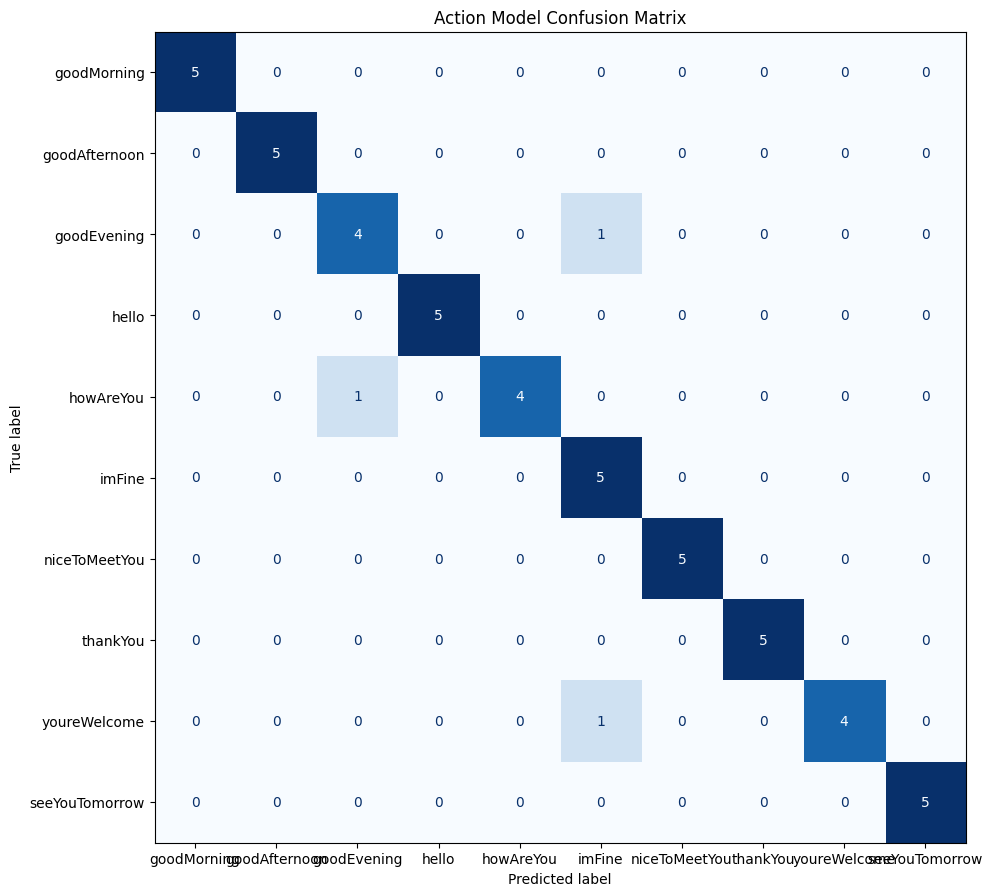

In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Get predictions
y_pred = modelAction.predict(x1_test)

# Convert from one-hot to class indices
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y1_test, axis=1)

# Confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Action Model Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

In [32]:
# Look at a few val samples and their labels
for i in range(5):
    print(f"Sample {i}: label={y2_test[i]}, face_center={x2_test[i][1]}")  
    # if landmarks look similar across classes, the data is the problem

class0 = x2_train[y2_train == 0].mean(axis=0)  # mean face neutral
class1 = x2_train[y2_train == 1].mean(axis=0)  # mean face questioning
diff = np.abs(class0 - class1)
print(f"Mean landmark difference: {diff.mean():.4f}")
print(f"Max landmark difference: {diff.max():.4f}")

Sample 0: label=0, face_center=0.12229359149932861
Sample 1: label=0, face_center=0.16002966463565826
Sample 2: label=0, face_center=0.1619976907968521
Sample 3: label=0, face_center=0.21966181695461273
Sample 4: label=0, face_center=0.1349247395992279
Mean landmark difference: 0.0122
Max landmark difference: 0.0792
